In [1]:
# !pip install ucimlrepo

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_recall_fscore_support, f1_score)
from lightgbm import LGBMClassifier

In [6]:
# fetch dataset
covertype = fetch_ucirepo(id=31)
X = covertype.data.features
y = covertype.data.targets

In [7]:
df = pd.concat([X, y], axis=1)

# **Data Profiling**

In [9]:
df.head(3)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2


In [13]:
df.shape

(581012, 55)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Soil_Type1                          581012 non-null 

In [15]:
df['Cover_Type'].nunique() #target classes

7

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
print("Numerical Stats:")
display(df.describe().T)

Numerical Stats:


,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [45]:
soil_cols = [f"Soil_Type{i}" for i in range(1, 41)]
ones_count = df[soil_cols].sum()
top_soil_types = df[soil_cols].sum().sort_values(ascending=False).head(5)
print(f'Top 5 Soil Types:\n {top_soil_types}')

Top 5 Soil Types:
 Soil_Type29    115247
Soil_Type23     57752
Soil_Type32     52519
Soil_Type33     45154
Soil_Type22     33373
dtype: int64


In [22]:
cover_type_counts = df['Cover_Type'].value_counts().sort_index()
print("\nCover Type Distribution:")
for cover_type, count in cover_type_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Type {cover_type}: {count:,} samples ({percentage:.1f}%)")


Cover Type Distribution:
Type 1: 211,840 samples (36.5%)
Type 2: 283,301 samples (48.8%)
Type 3: 35,754 samples (6.2%)
Type 4: 2,747 samples (0.5%)
Type 5: 9,493 samples (1.6%)
Type 6: 17,367 samples (3.0%)
Type 7: 20,510 samples (3.5%)


# **EDA**

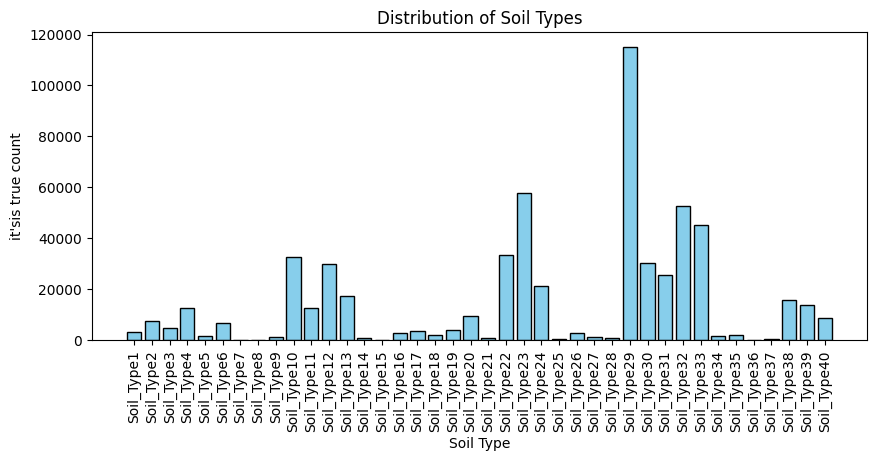

In [36]:
plt.figure(figsize=(10, 4))
plt.bar(ones_count.index, ones_count.values,color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Soil Type")
plt.ylabel("it'sis true count")
plt.title("Distribution of Soil Types")
plt.show()

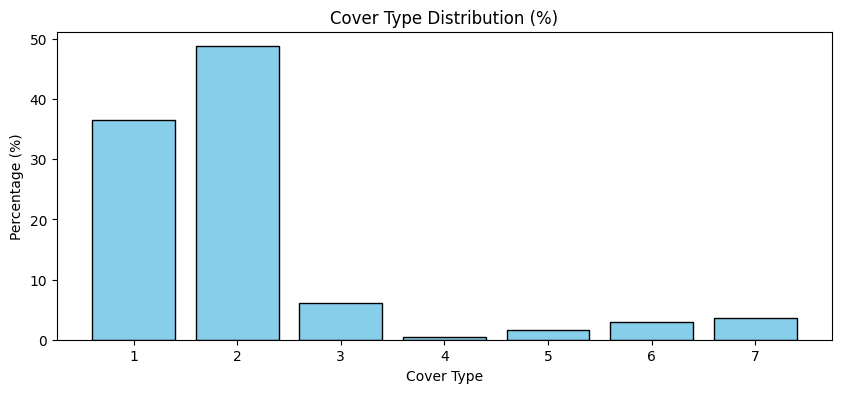

In [37]:
cover_type_percentages = (cover_type_counts / len(df)) * 100
plt.figure(figsize=(10, 4))
plt.bar(cover_type_percentages.index.astype(str), cover_type_percentages.values,color='skyblue', edgecolor='black')
plt.xlabel("Cover Type")
plt.ylabel("Percentage (%)")
plt.title("Cover Type Distribution (%)")
plt.show()

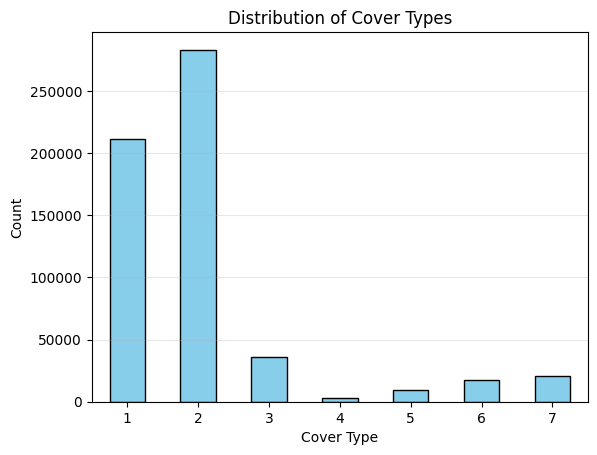

In [35]:
cover_type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cover Types Distribution')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

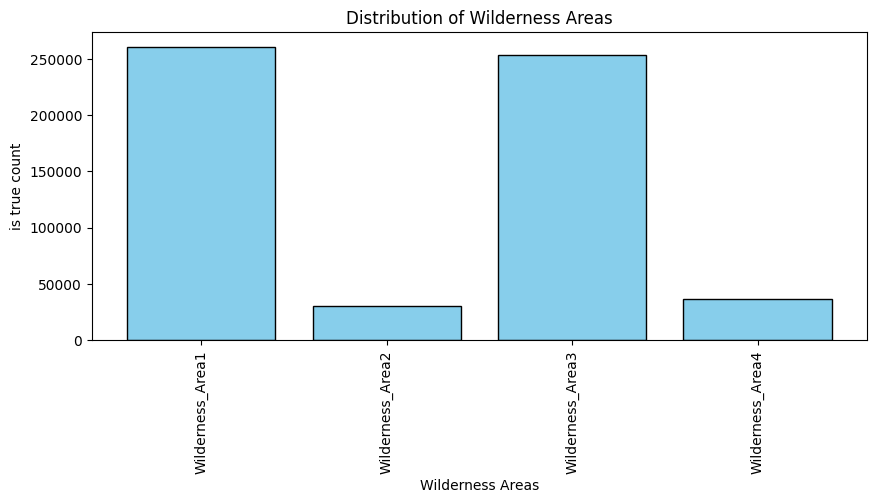

In [48]:
WildernessAreas = [f"Wilderness_Area{i}" for i in range(1, 5)]
WAreas_count = df[WildernessAreas].sum()
plt.figure(figsize=(10, 4))
plt.bar(WAreas_count.index, WAreas_count.values,color='skyblue', edgecolor='black')
plt.xticks(rotation=90)
plt.xlabel("Wilderness Areas")
plt.ylabel("is true count")
plt.title("Distribution of Wilderness Areas")
plt.show()

In [38]:
continuous_features = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                      'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                      'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                      'Horizontal_Distance_To_Fire_Points']


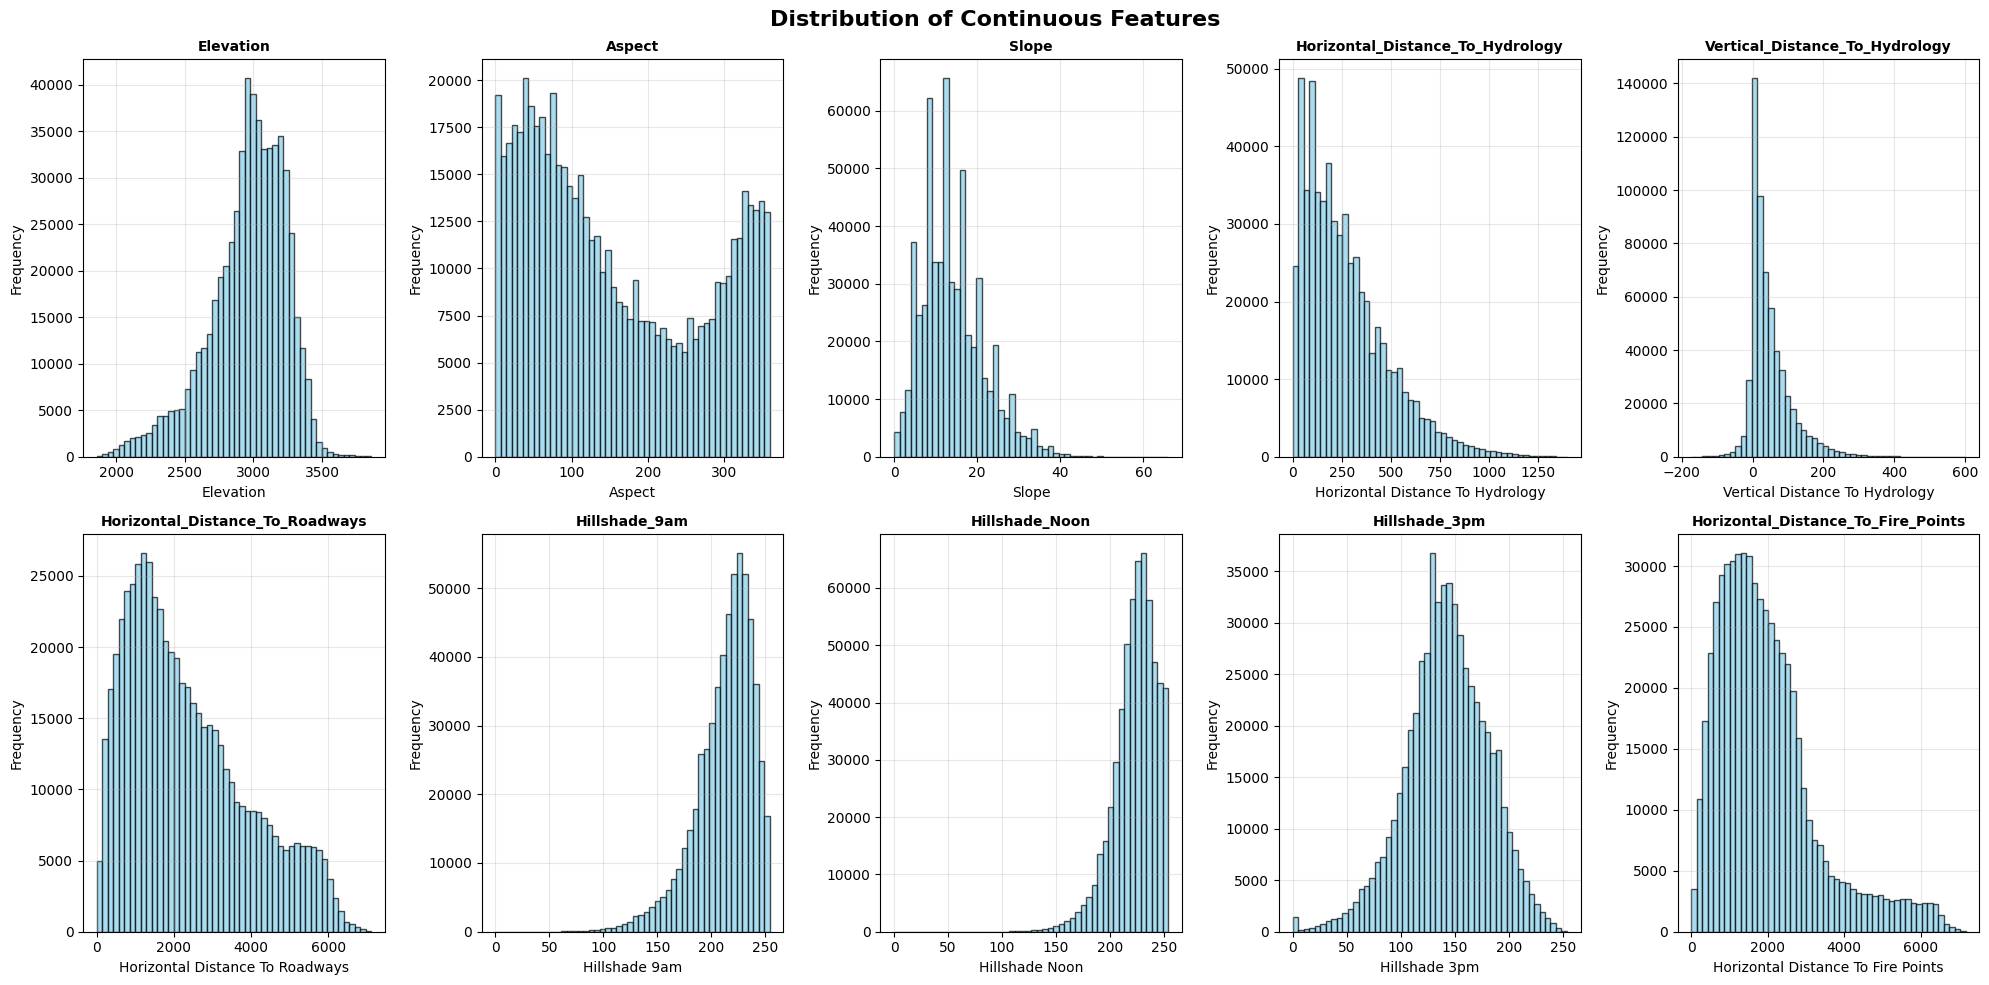

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()

for i, feature in enumerate(continuous_features):
    axes[i].hist(df[feature], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{feature}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feature.replace('_', ' '))
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.suptitle('Distribution of Continuous Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# **Data Preprocessing**

## Feature Engineering

In [92]:
df['total_distance_to_hydrology']=np.sqrt( (df['Horizontal_Distance_To_Hydrology']**2) + (df['Vertical_Distance_To_Hydrology']**2) )

In [93]:
df['hillshade_Mean']=(df['Hillshade_9am']+df['Hillshade_Noon']+df['Hillshade_3pm'])/3

In [94]:
df['hillshade_Range'] = (
    df[['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']].max(axis=1)
    -
    df[['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']].min(axis=1)
)

In [95]:
continuous_cols = continuous_features + ['total_distance_to_hydrology', 'hillshade_Mean', 'hillshade_Range']

## Splitting

In [101]:
X = df.drop(['Cover_Type'], axis=1)
y = df['Cover_Type']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [103]:
y_train_1d = y_train.values.ravel()
y_test_1d  = y_test.values.ravel()

In [104]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (464809, 57)
Test set: (116203, 57)


## Scaling

In [105]:
scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

In [106]:
X_train[continuous_cols] = scaler.transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# **Modeling**

In [107]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [108]:
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [109]:
y_predd = model.predict(X_test)

In [110]:
accuracy = accuracy_score(y_test, y_predd)
print("Accuracy:", accuracy)

Accuracy: 0.9479015171725342


In [111]:
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_predd))


Classification Report:

              precision    recall  f1-score   support

           1       0.96      0.93      0.95     42368
           2       0.94      0.97      0.96     56661
           3       0.93      0.95      0.94      7151
           4       0.90      0.84      0.87       549
           5       0.95      0.74      0.83      1899
           6       0.92      0.87      0.90      3473
           7       0.97      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.89      0.91    116203
weighted avg       0.95      0.95      0.95    116203



In [125]:
cm = confusion_matrix(y_test, y_predd)

[[39554  2706     4     0     7     4    93]
 [ 1383 55013   118     2    55    73    17]
 [    0   144  6827    26     3   151     0]
 [    0     0    66   459     0    24     0]
 [   29   442    20     0  1403     5     0]
 [    5   122   281    21     6  3038     0]
 [  221    26     0     0     0     0  3855]]


## more models

In [115]:
models = {
    'LightGBM': LGBMClassifier(
        n_estimators      = 500,       # more trees to compensate for lower complexity per tree
        learning_rate     = 0.05,      # lower lr + more estimators = closer to RF quality
        num_leaves        = 127,       # high enough to capture RF-level complexity
        max_depth         = -1,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 20,
        reg_alpha         = 0.1,
        reg_lambda        = 0.1,
        class_weight      = 'balanced',
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators  = 300,           # needs more trees than RF since it's sequential
        learning_rate = 0.1,
        max_depth     = 7,             # deeper trees to capture feature interactions
        min_samples_split = 5,
        min_samples_leaf  = 3,
        subsample     = 0.8,           # stochastic GB — reduces overfit
        max_features  = 'sqrt',        # like RF's feature sampling
        random_state  = 42
    )
}

In [116]:
results     = {}
f1_per_class = {}
classes     = sorted(np.unique(y_test_1d))

In [119]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_1d)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test_1d, y_pred)
    results[name] = acc
    f1_per_class[name] = f1_score(y_test_1d, y_pred, average=None, labels=classes)

    print(f"  Accuracy : {acc:.4f}")
    print(f"\n{classification_report(y_test_1d, y_pred)}")
    print("-" * 60)

Training LightGBM...
  Accuracy : 0.9476

              precision    recall  f1-score   support

           1       0.94      0.95      0.94     42368
           2       0.96      0.94      0.95     56661
           3       0.95      0.97      0.96      7151
           4       0.89      0.90      0.90       549
           5       0.82      0.96      0.89      1899
           6       0.91      0.95      0.93      3473
           7       0.95      0.98      0.97      4102

    accuracy                           0.95    116203
   macro avg       0.92      0.95      0.93    116203
weighted avg       0.95      0.95      0.95    116203

------------------------------------------------------------
Training Gradient Boosting...
  Accuracy : 0.8963

              precision    recall  f1-score   support

           1       0.90      0.87      0.88     42368
           2       0.89      0.92      0.91     56661
           3       0.92      0.93      0.92      7151
           4       0.81      0.7

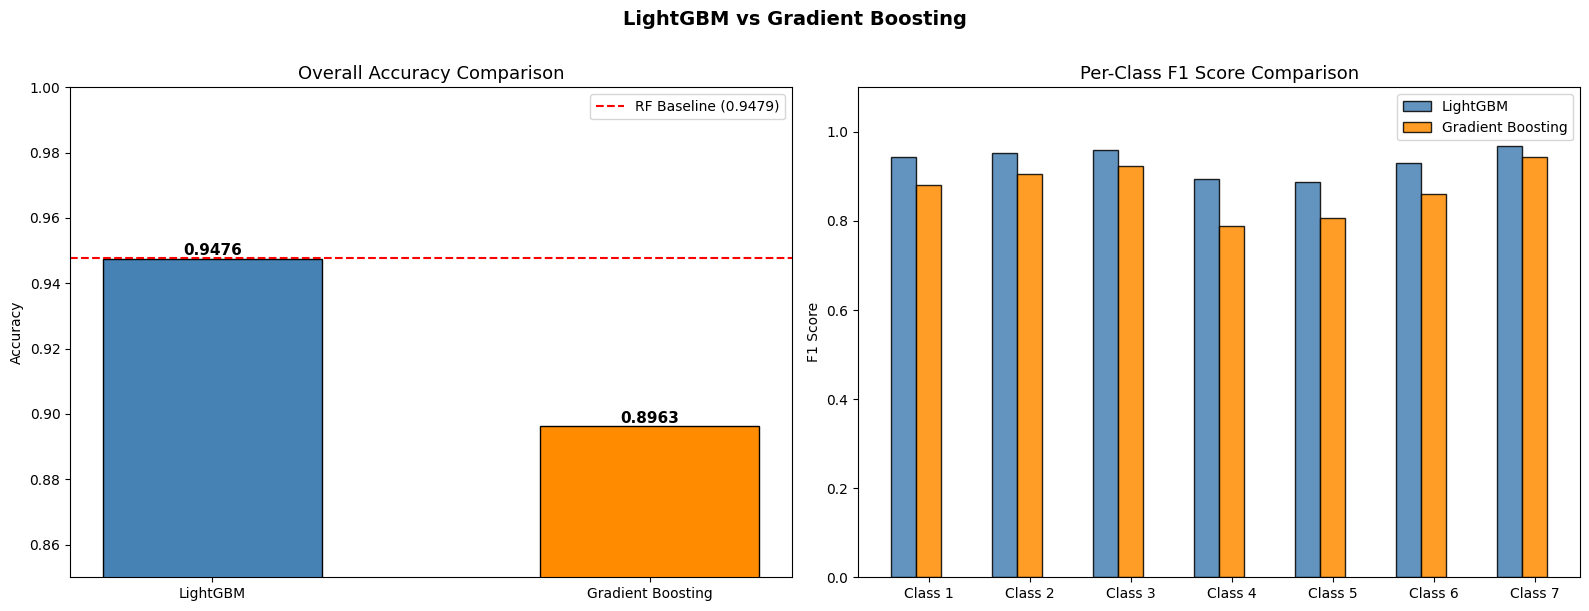

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['steelblue', 'darkorange', 'seagreen']
#Overall Accuracy Bar Chart
bars = axes[0].bar(results.keys(), results.values(), color=colors, edgecolor='black', width=0.5)
axes[0].axhline(y=0.9479, color='red', linestyle='--', linewidth=1.5, label='RF Baseline (0.9479)')
axes[0].set_ylim(0.85, 1.0)
axes[0].set_title('Overall Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
for bar, val in zip(bars, results.values()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}', ha='center', fontsize=11, fontweight='bold'
    )

# Per-Class F1 Grouped Bar Chart
x     = np.arange(len(classes))
width = 0.25

for i, (name, f1s) in enumerate(f1_per_class.items()):
    axes[1].bar(x + i * width, f1s, width, label=name, color=colors[i], alpha=0.85, edgecolor='black')

axes[1].set_xticks(x + width)
axes[1].set_xticklabels([f'Class {c}' for c in classes])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Per-Class F1 Score Comparison', fontsize=13)
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.suptitle('LightGBM vs Gradient Boosting', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()